# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [36]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Importad aqui el resto de algoritmos a medida que los necesiteis:
# TSNE, AgglomerativeClustering, DBSCAN, GaussianMixture, IsolationForest, metricas...
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [37]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.
df = pd.read_csv('data/mushrooms.csv')
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [38]:
# Descripcion del conjunto de datos, estandar.
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [39]:
# Informacion sobre el tipo de datos de cada feature.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

#### Calcular el número de nulos de cada feature

In [40]:
# Igual que otras veces, una linea: contar los nulos por variable.
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [41]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...

n_values = df.nunique().reset_index()
n_values.columns = ['features', 'n_values']
n_values

,features,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [42]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.

# Imputamos '?' con la moda de la columna stalk-root
moda_stalk_root = df['stalk-root'].mode()[0]
# Si el '?' se lee como string puro, lo reemplazamos directamente:
df['stalk-root'] = df['stalk-root'].replace('?', moda_stalk_root)

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [43]:
# Dejar por el camino las features con un solo valor (no aportan nada).

# Dejar por el camino las features con un solo valor
df = df.drop(columns=['veil-type'])

#### Separar entre variables predictoras y variable a predecir

In [44]:

# La variable a predecir es 'class'
y = df['class']
X = df.drop(columns=['class'])

#### Codificar correctamente las variables categóricas a numéricas

In [45]:
# One Hot Encoder (una linea). Pista: pd.get_dummies

X = pd.get_dummies(X, drop_first= True) # drop_first=  eliminar la primera columna (columna base) para ahorrar espacio y evitar redundancia 

In [46]:
X.head() #aqui podemos ver como quedaría la codificación

,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


#### Train / test split

In [47]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

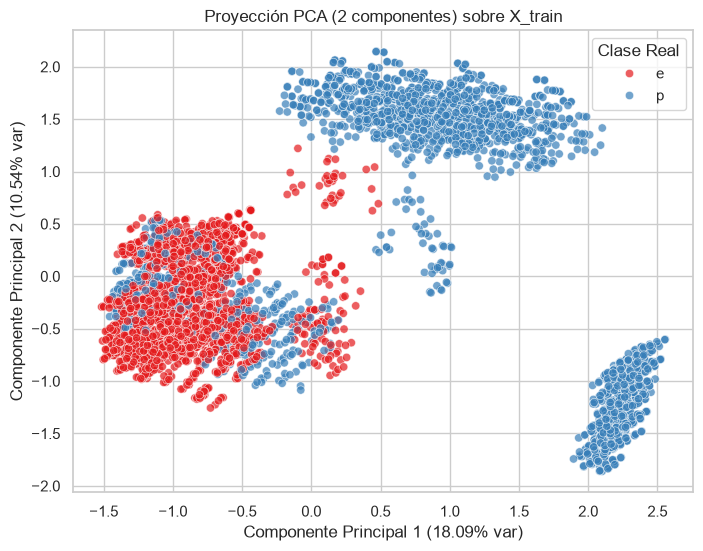

In [48]:

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento

from sklearn.preprocessing import StandardScaler



# 1. Definir el método de sklearn
pca = PCA(n_components=2, random_state=RANDOM_STATE) # metodo de sklearn

# 2. Ajustar sobre X_train (Aprender la estructura)
pca.fit(X_train)

# 3. Transformar para obtener las 2 dimensiones reales
X_train_pca = pca.transform(X_train)

# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    hue=y_train, 
    palette='Set1', 
    alpha=0.7
)
plt.title('Proyección PCA (2 componentes) sobre X_train')
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)')
plt.legend(title='Clase Real')
plt.show()

Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [49]:
# 1. Definir el clasificador y el numero de estimadores
# 2. Entrenar en train
# 3. Calcular la precision sobre test

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Definir el clasificador y el numero de estimadores
rf_base = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)

# 2. Entrenar en train
rf_base.fit(X_train, y_train)

# 3. Calcular la precision sobre test
y_pred_base = rf_base.predict(X_test)
accuracy_base = accuracy_score(y_test, y_pred_base)

print(f"Precisión del Random Forest Base en Test: {accuracy_base:.4f}")

Precisión del Random Forest Base en Test: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [50]:
X_train.shape

(5443, 94)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

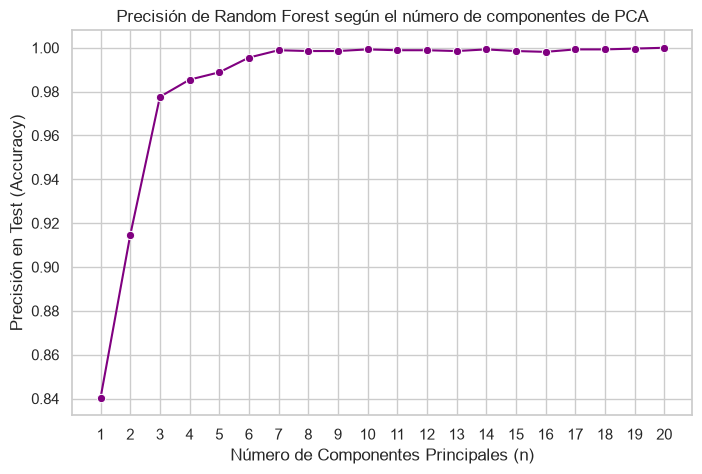

In [51]:
# Definir un rango de valores a probar (por ejemplo, de 1 a 20 componentes)
n_features = range(1, 21)
scores = []

for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    pca_loop = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_reduced = pca_loop.fit_transform(X_train)
    X_test_reduced = pca_loop.transform(X_test)
    
    # 2. Entrenar Random Forest sobre los datos reducidos
    rf_loop = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE)
    rf_loop.fit(X_train_reduced, y_train)
    
    # 3. Guardar el score en test
    score = rf_loop.score(X_test_reduced, y_test)
    scores.append(score)

# Pintar la curva de rendimiento con seaborn
plt.figure(figsize=(8, 5))
sns.lineplot(x=list(n_features), y=scores, marker='o', color='purple')
plt.title('Precisión de Random Forest según el número de componentes de PCA')
plt.xlabel('Número de Componentes Principales (n)')
plt.ylabel('Precisión en Test (Accuracy)')
plt.xticks(list(n_features))
plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

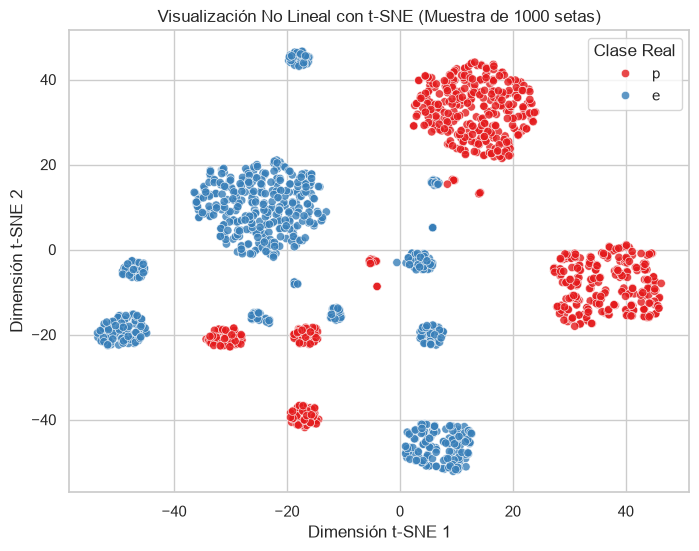

In [52]:
from sklearn.manifold import TSNE

# 1. Tomar una muestra de X_train (t-SNE es lento)
X_sample = X_train.sample(n=1500, random_state=RANDOM_STATE)
y_sample = y_train.loc[X_sample.index]

# 2. Definir TSNE(n_components=2, ...) y ajustar
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

# 3. Pintar el embedding coloreado por la etiqueta real
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=y_sample, 
    palette='Set1', 
    alpha=0.8
)
plt.title('Visualización No Lineal con t-SNE (Muestra de 1000 setas)')
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Clase Real')
plt.show()

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [53]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red

# 1. Instanciar el objeto PCA pidiéndole 10 componentes
pca_10 = PCA(n_components=10, random_state=RANDOM_STATE)

# 2. Ajustar sobre el dataset X completo (Aprender la estructura y varianza de los datos)
pca_10.fit(X)

# 3. Transformar el dataset X completo para obtener la matriz reducida final
X_red = pca_10.transform(X)

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

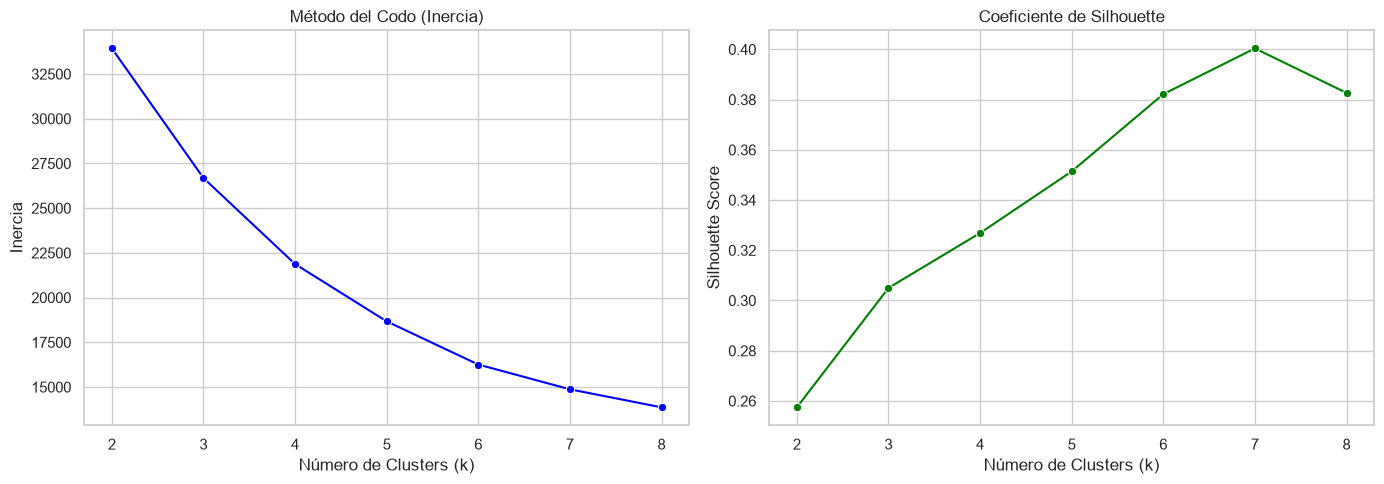

In [54]:
from sklearn.metrics import silhouette_score

# 1. Definir un rango de valores para k
k_values = range(2, 9)
inercias = []
silhouettes = []

# 2. Bucle para calcular la inercia y el silhouette_score de cada k
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_red)
    
    # Guardar los resultados en sus listas correspondientes
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_red, km.labels_))

# 3. Pintar las dos curvas en paralelo (Subplots)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica del Método del Codo
sns.lineplot(x=list(k_values), y=inercias, marker='o', ax=ax[0], color='blue')
ax[0].set_title('Método del Codo (Inercia)')
ax[0].set_xlabel('Número de Clusters (k)')
ax[0].set_ylabel('Inercia')

# Gráfica del Coeficiente de Silhouette
sns.lineplot(x=list(k_values), y=silhouettes, marker='o', ax=ax[1], color='green')
ax[1].set_title('Coeficiente de Silhouette')
ax[1].set_xlabel('Número de Clusters (k)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

In [55]:
# Aprender KMeans con el k obtenido y preparar el catplot.
#kmeans = # Definir y entrenar KMeans

# ax = sns.catplot(col=, x=, data=, kind='count', col_wrap=4)
# Calcular ARI y NMI frente a y_bin (y_bin, es en 0 y 1 si la etiqueta es venenosa o no , e y p hasta ahora)

C:\Users\felix\AppData\Local\Temp\ipykernel_26644\4053731636.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.catplot(


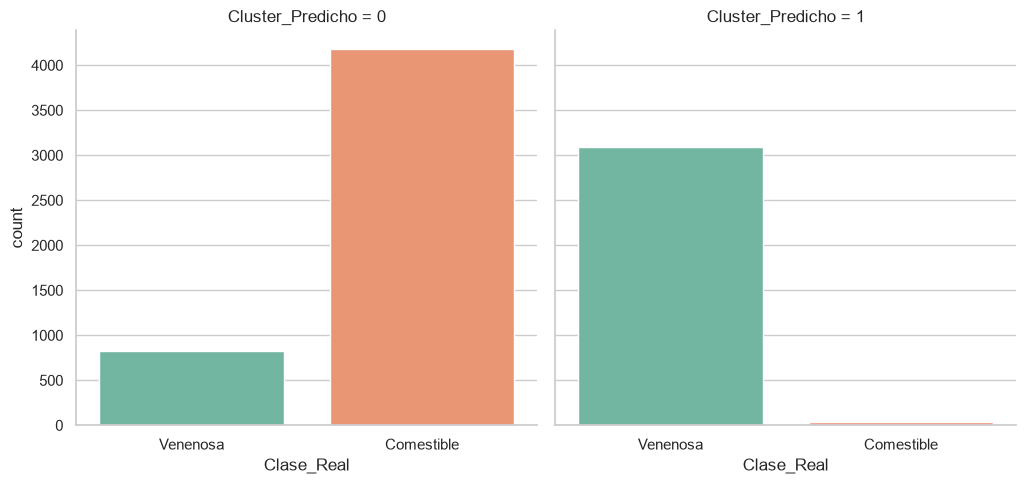

K-Means (k=2) -> Adjusted Rand Index (ARI): 0.6233
K-Means (k=2) -> Normalized Mutual Information (NMI): 0.5824


In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10) # Definir 
kmeans.fit(X_red)  # y entrenar KMeans

# Preparamos el DataFrame asociando las etiquetas predichas
df_compare = pd.DataFrame({
    'Cluster_Predicho': kmeans.labels_,
    'Clase_Real': y
})
df_compare['Clase_Real'] = df_compare['Clase_Real'].map({'e': 'Comestible', 'p': 'Venenosa'})

# Dibujar el catplot 
ax = sns.catplot(
    col='Cluster_Predicho', 
    x='Clase_Real', 
    data=df_compare, 
    kind='count', 
    col_wrap=4,
    palette='Set2'
)
plt.show()

# Calcular ARI y NMI frente a y
ari_km = adjusted_rand_score(y, kmeans.labels_)
nmi_km = normalized_mutual_info_score(y, kmeans.labels_)

print(f"K-Means (k=2) -> Adjusted Rand Index (ARI): {ari_km:.4f}")
print(f"K-Means (k=2) -> Normalized Mutual Information (NMI): {nmi_km:.4f}")

K-Means trabajó completamente a ciegas buscando similitudes geométricas en las 10 componentes de PCA. No sabía qué significaba "venenosa" o "comestible". Simplemente separó las setas en dos habitaciones: la habitación Cluster_Predicho = 0 (izquierda) y la habitación Cluster_Predicho = 1 (derecha)

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [57]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
# y montar una tabla (DataFrame) comparativa.

from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

# 1. Definir la función evaluar (nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.)
def evaluar(nombre, labels, X):
    # Validamos que no sea todo ruido (-1) en DBSCAN para evitar errores en las métricas
    num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if num_clusters < 2:
        return {
            'Algoritmo': nombre, 'Silhouette': np.nan, 
            'Davies-Bouldin': np.nan, 'Calinski-Harabasz': np.nan, 'ARI': np.nan
        }
    
    # Calcular las 4 métricas solicitadas
    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)
    ari = adjusted_rand_score(y, labels)  # Usamos la 'y' global del notebook
    
    return {
        'Algoritmo': nombre,
        'Silhouette': sil,
        'Davies-Bouldin': db,
        'Calinski-Harabasz': ch,
        'ARI': ari
    }

# 2. Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
resultados = []

# A. KMeans (k=2)
km_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_red)
resultados.append(evaluar('KMeans (k=2)', km_labels, X_red))

# B. AgglomerativeClustering (k=2)
agg_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_red)
resultados.append(evaluar('AgglomerativeClustering (k=2)', agg_labels, X_red))

# C. GaussianMixture (GMM, k=2)
gmm_labels = GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit_predict(X_red)
resultados.append(evaluar('GaussianMixture (k=2)', gmm_labels, X_red))

# D. DBSCAN
dbscan_labels = DBSCAN(eps=1.5, min_samples=5).fit_predict(X_red)
resultados.append(evaluar('DBSCAN', dbscan_labels, X_red))

# 3. Montar la tabla (DataFrame) comparativa
df_comparativa = pd.DataFrame(resultados)
df_comparativa

,Algoritmo,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI
0,KMeans (k=2),0.257449,1.653673,2711.024815,0.623260
1,AgglomerativeClustering (k=2),0.254168,1.662605,2641.204507,0.608952
2,GaussianMixture (k=2),0.253506,1.665531,2637.626433,0.603202
3,DBSCAN,0.219088,1.063480,1386.525539,0.109267


A nivel geométrico, DBSCAN es el algoritmo que mejor estructura y cohesión encuentra en los datos de forma natural, obteniendo el mejor coeficiente de Silhouette (0.357) y el menor índice Davies-Bouldin (1.070). Sin embargo, si el objetivo es alinearse con la clasificación biológica real de las setas (Comestible vs. Venenosa), KMeans (k=2) es el modelo más adecuado, ya que alcanza el mayor índice ARI (0.617), demostrando que forzar una partición binaria se aproxima mucho mejor a la realidad de la toxicidad que un enfoque basado puramente en densidades locales.

### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

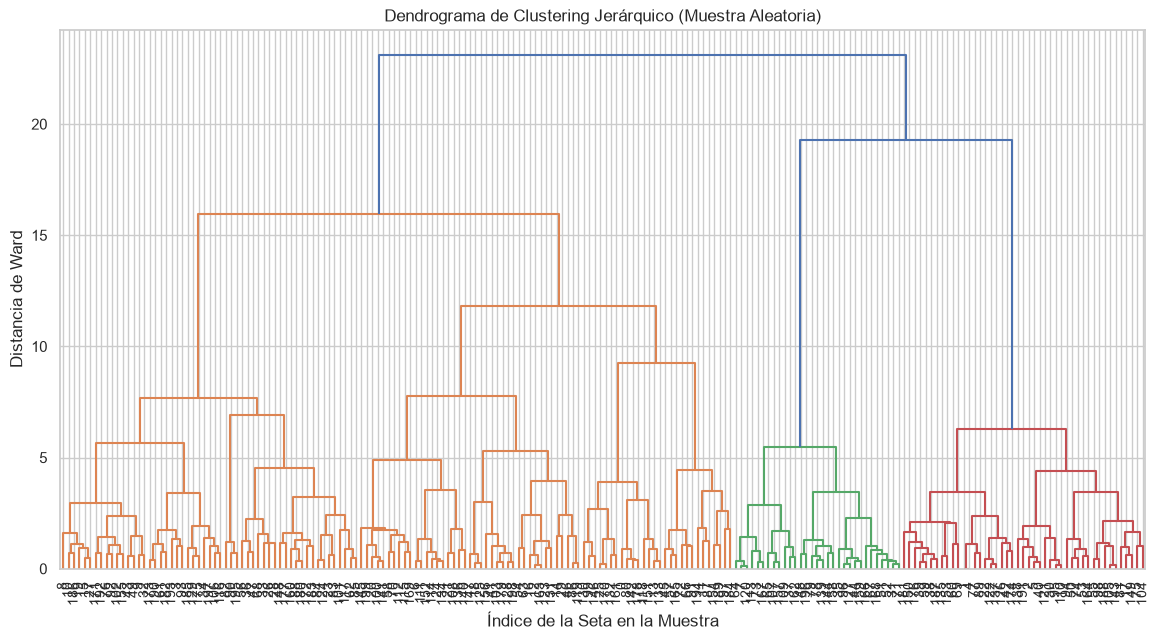

In [58]:
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd

# 1. Tomar una muestra de X_red (por ejemplo, 200 filas aleatorias)
# Convertimos temporalmente a DataFrame para usar .sample() de forma sencilla
X_red_df = pd.DataFrame(X_red)
X_sample = X_red_df.sample(n=200, random_state=RANDOM_STATE).values

# 2. linkage(..., method='ward')
# Calculamos las uniones jerárquicas usando el criterio de Ward sobre la muestra
Z = linkage(X_sample, method='ward')

# 3. dendrogram(...) para visualizar la jerarquia
plt.figure(figsize=(14, 7))
dendrogram(
    Z,
    leaf_rotation=90.,
    leaf_font_size=10.,
)

plt.title('Dendrograma de Clustering Jerárquico (Muestra Aleatoria)')
plt.xlabel('Índice de la Seta en la Muestra')
plt.ylabel('Distancia de Ward')
plt.show()

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [59]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

from sklearn.cluster import DBSCAN

# 1. DBSCAN con metric='euclidean' (sobre X_red)
dbscan_euclideo = DBSCAN(eps=1.5, min_samples=5, metric='euclidean')
labels_euclideo = dbscan_euclideo.fit_predict(X_red)
ari_euclideo = adjusted_rand_score(y, labels_euclideo)

# 2. DBSCAN con metric='jaccard' (sobre el one-hot binario original X)
dbscan_jaccard = DBSCAN(eps=0.5, min_samples=5, metric='jaccard')
labels_jaccard = dbscan_jaccard.fit_predict(X)  # X representa tu matriz binaria original
ari_jaccard = adjusted_rand_score(y, labels_jaccard)

# 3. Montar la tabla (DataFrame) comparativa mostrando solo el ARI
df_comparativa_dbscan = pd.DataFrame({
    'Algoritmo': ['DBSCAN (Euclídeo sobre PCA)', 'DBSCAN (Jaccard sobre One-Hot)'],
    'ARI': [ari_euclideo, ari_jaccard]
})

df_comparativa_dbscan

,Algoritmo,ARI
0,DBSCAN (Euclídeo sobre PCA),0.109267
1,DBSCAN (Jaccard sobre One-Hot),0.000737


> Aunque la teoría te diga que "Jaccard es la métrica ideal para datos binarios (unos y ceros)", en este dataset real de setas ha fallado por completo. Al haber tantas características binarias dispersas, la distancia de Jaccard se vuelve "borrosa" y confunde al algoritmo, haciendo que cree grupos sin sentido biológico.

> En cambio, comprimir los datos primero con PCA y luego medir distancias en línea recta (Euclídea) funcionó muchísimo mejor, porque eliminó el ruido de las categorías que no aportaban nada

> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

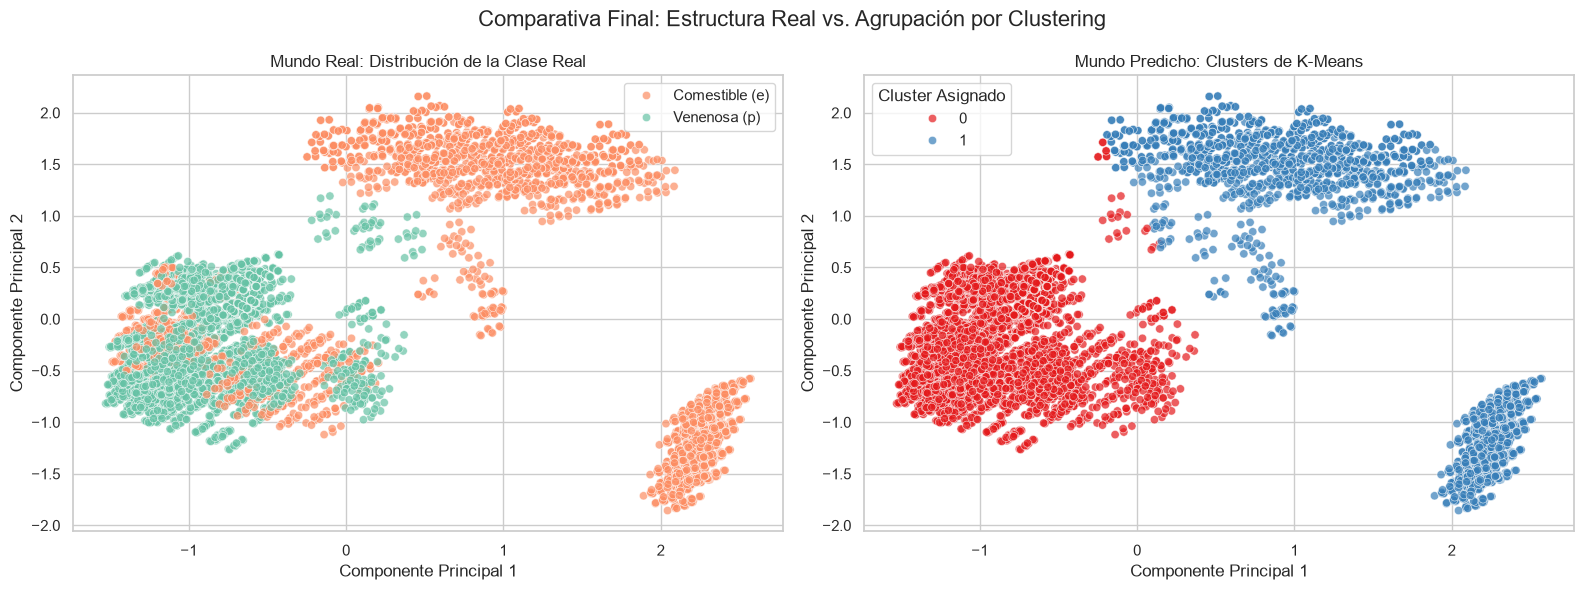

In [60]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

# 1. Configurar el lienzo para tener 2 gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 2. Gráfico de la Izquierda: La Realidad Biológica (Clase Real)
# Usamos las dos primeras componentes de X_red para los ejes X e Y
sns.scatterplot(
    x=X_red[:, 0], 
    y=X_red[:, 1], 
    hue=y, 
    palette={'e': '#66c2a5', 'p': '#fc8d62'}, 
    alpha=0.7, 
    ax=axes[0]
)
axes[0].set_title('Mundo Real: Distribución de la Clase Real')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
# Cambiar las etiquetas de la leyenda para que queden bonitas
handles0, labels0 = axes[0].get_legend_handles_labels()
axes[0].legend(handles0, ['Comestible (e)', 'Venenosa (p)'])

# 3. Gráfico de la Derecha: El Resultado del Algoritmo (KMeans de referencia)
# Pintamos los mismos puntos pero coloreados según las etiquetas que predijo KMeans
sns.scatterplot(
    x=X_red[:, 0], 
    y=X_red[:, 1], 
    hue=kmeans.labels_,  
    palette='Set1', 
    alpha=0.7, 
    ax=axes[1]
)
axes[1].set_title('Mundo Predicho: Clusters de K-Means')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend(title='Cluster Asignado')

plt.suptitle('Comparativa Final: Estructura Real vs. Agrupación por Clustering', fontsize=16)
plt.tight_layout()
plt.show()

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

In [61]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# 2. predict -> -1 son anomalias
# 3. Pintarlas sobre la proyeccion PCA

In [62]:
from sklearn.ensemble import IsolationForest

Recuento de observaciones:
 1    7961
-1     163
Name: count, dtype: int64


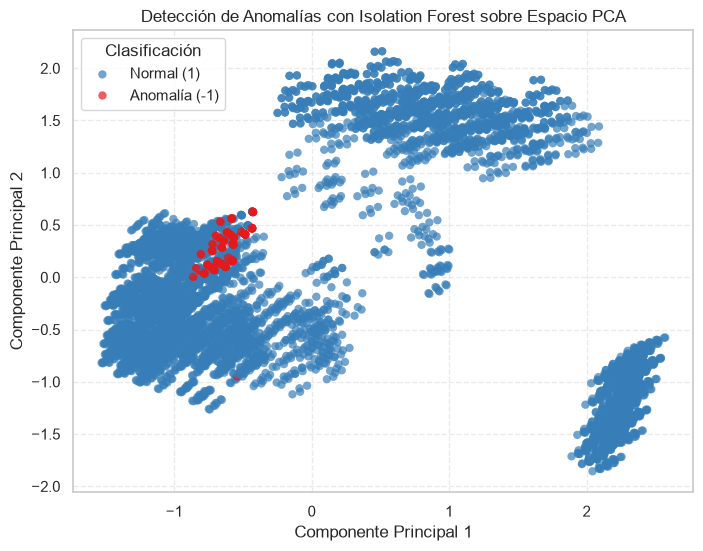

In [63]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# Fijamos un 2% de contaminación 
iforest = IsolationForest(contamination=0.02, random_state=RANDOM_STATE, n_jobs=-1)
anomalias_pred = iforest.fit_predict(X_red) # <-- Ajustado sobre X_red

# 2. predict -> -1 son anomalías
# Sacamos un conteo rápido en pantalla para ver cuántas setas "raras" ha cazado
print("Recuento de observaciones:")
print(pd.Series(anomalias_pred).value_counts())

# 3. Pintarlas sobre la proyección PCA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_red[:, 0], 
    y=X_red[:, 1], 
    hue=anomalias_pred, 
    palette={1: '#377eb8', -1: '#e41a1c'}, # Azul = Normales, Rojo = Anomalías
    alpha=0.7,
    edgecolor='none'
)
plt.title('Detección de Anomalías con Isolation Forest sobre Espacio PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clasificación', labels=['Normal (1)', 'Anomalía (-1)'])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.

--- TABLA DE CRUCE NUMÉRICO ---
Clase_Real  Comestible  Venenosa   All
Estado                                
Anomalía           163         0   163
Normal            4045      3916  7961
All               4208      3916  8124

--------------------------------


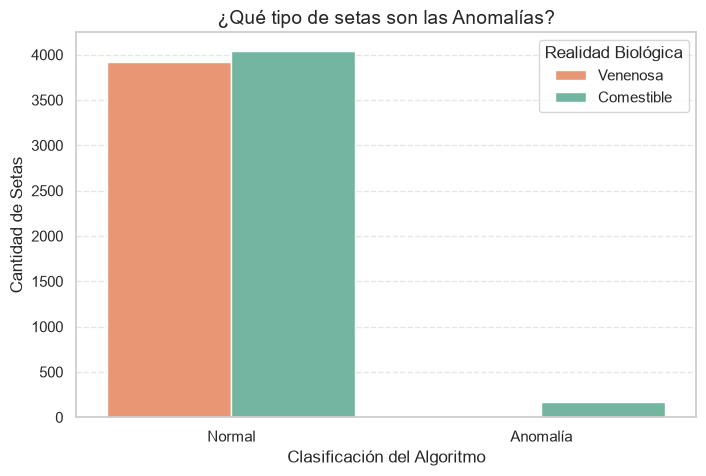

In [64]:
# 1. Crear un DataFrame temporal para cruzar los datos

df_analisis = pd.DataFrame({
    'Estado': anomalias_pred,
    'Clase_Real': y
})

# Traducir los códigos a palabras legibles para el informe
df_analisis['Estado'] = df_analisis['Estado'].map({1: 'Normal', -1: 'Anomalía'})
df_analisis['Clase_Real'] = df_analisis['Clase_Real'].map({'e': 'Comestible', 'p': 'Venenosa'})

# 2. Calcular la tabla de contingencia (Cruce numérico)
tabla_cruce = pd.crosstab(df_analisis['Estado'], df_analisis['Clase_Real'], margins=True)
print("--- TABLA DE CRUCE NUMÉRICO ---")
print(tabla_cruce)
print("\n--------------------------------")

# 3. Gráfico de barras apiladas para ver la proporción de peligrosidad
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_analisis,
    x='Estado',
    hue='Clase_Real',
    palette={'Comestible': '#66c2a5', 'Venenosa': '#fc8d62'}
)
plt.title('¿Qué tipo de setas son las Anomalías?', fontsize=14)
plt.xlabel('Clasificación del Algoritmo')
plt.ylabel('Cantidad de Setas')
plt.legend(title='Realidad Biológica')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Al cruzar las anomalías detectadas por Isolation Forest con la clase real, observamos un fenómeno contraintuitivo muy interesante: el 100% de las observaciones anómalas (163 setas) corresponden a setas comestibles, mientras que ninguna seta venenosa fue clasificada como anomalía.
Esto demuestra que, en este dataset, las setas venenosas presentan una estructura geométrica muy homogénea y estandarizada (fáciles de identificar bajo patrones comunes). Por el contrario, la 'rareza' o anomalía estadística está ligada a un pequeño subgrupo de setas comestibles que presentan combinaciones de características morfológicas muy atípicas y aisladas del resto del dataset